In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv(r'C:\Users\Vaidu Mistry\Downloads\gaming_addiction.csv')

In [3]:
df

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,USR000246,23,Female,Japan,Streamer/Content Creator,Upper-Middle,11,MMORPG,PC+Console,Console,...,4,180.9,7.2,Streamer/Creator,42.37,0,Moderate,1.0,0.395,0.590
246,USR000247,18,Male,India,Student,Low,6,Sandbox,PC,Mid-range PC,...,0,91.5,5.6,Social Gamer,22.45,0,Mild,1.0,0.715,0.803
247,USR000248,20,Male,USA,Student,Middle,8,MMORPG,Mobile,Console,...,8,120.6,4.9,Escape Seeker,34.76,0,Mild,1.0,0.410,0.939
248,USR000249,19,Male,South Korea,Employed,Middle,7,Sandbox,PC+Console,High-end PC,...,2,175.9,5.2,Social Gamer,36.60,0,Mild,1.0,0.405,0.870


In [4]:
df.head()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


In [5]:
df.tail()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
245,USR000246,23,Female,Japan,Streamer/Content Creator,Upper-Middle,11,MMORPG,PC+Console,Console,...,4,180.9,7.2,Streamer/Creator,42.37,0,Moderate,1.0,0.395,0.590
246,USR000247,18,Male,India,Student,Low,6,Sandbox,PC,Mid-range PC,...,0,91.5,5.6,Social Gamer,22.45,0,Mild,1.0,0.715,0.803
247,USR000248,20,Male,USA,Student,Middle,8,MMORPG,Mobile,Console,...,8,120.6,4.9,Escape Seeker,34.76,0,Mild,1.0,0.410,0.939
248,USR000249,19,Male,South Korea,Employed,Middle,7,Sandbox,PC+Console,High-end PC,...,2,175.9,5.2,Social Gamer,36.60,0,Mild,1.0,0.405,0.870
249,USR000250,27,Male,USA,Unemployed,Middle,14,MMORPG,PC+Mobile,Laptop,...,4,131.7,4.8,Social Gamer,41.65,0,Moderate,1.0,0.605,0.733


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      250 non-null    object 
 1   age                          250 non-null    int64  
 2   gender                       250 non-null    object 
 3   country                      250 non-null    object 
 4   occupation                   250 non-null    object 
 5   income_level                 250 non-null    object 
 6   years_gaming                 250 non-null    int64  
 7   preferred_genre              250 non-null    object 
 8   platform                     250 non-null    object 
 9   device_type                  250 non-null    object 
 10  rank_tier                    250 non-null    object 
 11  daily_playtime_hours         250 non-null    float64
 12  weekly_play_sessions         250 non-null    int64  
 13  late_night_sessions_

In [7]:
df.describe()

,age,years_gaming,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,...,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,addiction_binary,burnout_probability,mental_health_risk_score,churn_probability
count,250.000000,250.000000,250.000000,250.000000,250.0000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,22.160000,9.668000,6.153200,7.056000,2.1024,8.368400,9.714800,0.462240,2.948000,1.896000,...,2.828000,15.986400,5.52400,99.253200,8.239600,38.74448,0.168000,0.996856,0.509640,0.795556
std,5.455037,5.460866,2.656902,3.517721,1.2007,4.085876,4.828877,0.227391,5.451621,2.353581,...,2.088027,10.581607,3.14212,55.057918,2.894558,11.74977,0.374616,0.043240,0.140448,0.120904
min,13.000000,1.000000,0.500000,1.000000,0.0000,0.500000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,5.000000,1.200000,12.28000,0.000000,0.320000,0.120000,0.150000
25%,18.000000,6.000000,4.225000,4.000000,1.1250,5.600000,5.525000,0.300000,0.000000,0.000000,...,1.000000,8.150000,3.00000,61.375000,6.200000,29.88250,0.000000,1.000000,0.406250,0.732250
50%,22.000000,9.000000,6.450000,7.000000,2.1000,8.150000,10.100000,0.450000,1.000000,1.000000,...,3.000000,15.900000,6.00000,99.150000,8.200000,39.87500,0.000000,1.000000,0.515000,0.808000
75%,27.000000,14.750000,8.175000,10.000000,3.0000,10.850000,13.175000,0.630000,2.000000,3.000000,...,4.000000,22.975000,8.00000,133.575000,10.500000,47.11000,0.000000,1.000000,0.600000,0.878000
max,40.000000,25.000000,11.900000,15.000000,5.2000,20.000000,20.600000,1.000000,32.000000,10.000000,...,8.000000,44.200000,14.00000,255.500000,15.100000,68.00000,1.000000,1.000000,0.920000,1.000000


In [8]:
df.isnull().sum()

user_id                         0
age                             0
gender                          0
country                         0
occupation                      0
income_level                    0
years_gaming                    0
preferred_genre                 0
platform                        0
device_type                     0
rank_tier                       0
daily_playtime_hours            0
weekly_play_sessions            0
late_night_sessions_hours       0
weekend_playtime_hours          0
consecutive_hours_max           0
multiplayer_ratio               0
toxic_chat_reports              0
rage_quit_frequency             0
in_game_purchases               0
monthly_spending_usd            0
lootbox_openings                0
subscription_status            82
stress_score                    0
loneliness_score                0
dopamine_dependency_index       0
self_control_score              0
impulsiveness_score             0
anxiety_level                   0
depression_ind

In [9]:
df['subscription_status'] = df['subscription_status'].fillna(df['subscription_status'].mode()[0])

In [10]:
df['depression_indicator'] = df['depression_indicator'].fillna(df['depression_indicator'].mode()[0])
df['addiction_severity'] = df['addiction_severity'].fillna(df['addiction_severity'].mode()[0])

In [11]:
df = df.dropna()

In [12]:
df.isnull().sum()

user_id                        0
age                            0
gender                         0
country                        0
occupation                     0
income_level                   0
years_gaming                   0
preferred_genre                0
platform                       0
device_type                    0
rank_tier                      0
daily_playtime_hours           0
weekly_play_sessions           0
late_night_sessions_hours      0
weekend_playtime_hours         0
consecutive_hours_max          0
multiplayer_ratio              0
toxic_chat_reports             0
rage_quit_frequency            0
in_game_purchases              0
monthly_spending_usd           0
lootbox_openings               0
subscription_status            0
stress_score                   0
loneliness_score               0
dopamine_dependency_index      0
self_control_score             0
impulsiveness_score            0
anxiety_level                  0
depression_indicator           0
emotional_

In [15]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'occupation', 'income_level',
       'years_gaming', 'preferred_genre', 'platform', 'device_type',
       'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions',
       'late_night_sessions_hours', 'weekend_playtime_hours',
       'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports',
       'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd',
       'lootbox_openings', 'subscription_status', 'stress_score',
       'loneliness_score', 'dopamine_dependency_index', 'self_control_score',
       'impulsiveness_score', 'anxiety_level', 'depression_indicator',
       'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week',
       'caffeine_intake_cups_day', 'social_interaction_hours',
       'relationship_status', 'gpa_or_performance_score', 'missed_deadlines',
       'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps',
       'screen_time_total_hours', 'behavioral_cluster', 'addicti

In [16]:
df = df.drop(columns = ['user_id','addiction_binary','addiction_severity','behavioral_cluster'])

In [17]:
df.columns

Index(['age', 'gender', 'country', 'occupation', 'income_level',
       'years_gaming', 'preferred_genre', 'platform', 'device_type',
       'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions',
       'late_night_sessions_hours', 'weekend_playtime_hours',
       'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports',
       'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd',
       'lootbox_openings', 'subscription_status', 'stress_score',
       'loneliness_score', 'dopamine_dependency_index', 'self_control_score',
       'impulsiveness_score', 'anxiety_level', 'depression_indicator',
       'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week',
       'caffeine_intake_cups_day', 'social_interaction_hours',
       'relationship_status', 'gpa_or_performance_score', 'missed_deadlines',
       'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps',
       'screen_time_total_hours', 'addiction_score', 'burnout_probability',

In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
le = LabelEncoder()

In [21]:
df['gender'] = le.fit_transform(df['gender'])
df['country'] = le.fit_transform(df['country'])
df['occupation'] = le.fit_transform(df['occupation'])
df['income_level'] = le.fit_transform(df['income_level'])
df['preferred_genre'] = le.fit_transform(df['preferred_genre'])
df['platform'] = le.fit_transform(df['platform'])
df['device_type'] = le.fit_transform(df['device_type'])
df['rank_tier'] = le.fit_transform(df['rank_tier'])
df['subscription_status'] = le.fit_transform(df['subscription_status'])
df['relationship_status'] = le.fit_transform(df['relationship_status'])

In [22]:
df

,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,...,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,burnout_probability,mental_health_risk_score,churn_probability
0,21,1,6,0,3,9,7,2,2,2,...,4.00,4,0.0,7,39.9,5.4,27.61,1.0,0.920,1.000
1,25,1,6,0,2,13,6,1,4,0,...,4.00,4,16.7,6,71.5,13.4,55.51,1.0,0.515,0.813
2,26,1,1,0,3,14,6,4,1,4,...,4.00,6,8.5,7,119.4,12.3,45.85,1.0,0.720,0.947
3,22,1,12,0,4,10,9,4,5,0,...,4.00,3,8.7,8,136.5,6.9,39.87,1.0,0.520,0.660
4,17,0,6,3,3,5,9,2,2,0,...,2.60,3,21.9,6,78.8,9.3,46.97,1.0,0.585,0.867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,18,1,6,0,3,6,4,0,4,1,...,4.00,4,0.0,4,100.0,9.1,36.42,1.0,0.590,0.808
245,23,0,8,2,4,11,4,3,0,5,...,4.00,1,17.6,4,180.9,7.2,42.37,1.0,0.395,0.590
246,18,1,6,3,1,6,7,2,3,0,...,2.73,0,0.0,0,91.5,5.6,22.45,1.0,0.715,0.803
247,20,1,14,3,3,8,4,1,0,0,...,2.80,1,0.0,8,120.6,4.9,34.76,1.0,0.410,0.939


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 240 entries, 0 to 249
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          240 non-null    int64  
 1   gender                       240 non-null    int64  
 2   country                      240 non-null    int64  
 3   occupation                   240 non-null    int64  
 4   income_level                 240 non-null    int64  
 5   years_gaming                 240 non-null    int64  
 6   preferred_genre              240 non-null    int64  
 7   platform                     240 non-null    int64  
 8   device_type                  240 non-null    int64  
 9   rank_tier                    240 non-null    int64  
 10  daily_playtime_hours         240 non-null    float64
 11  weekly_play_sessions         240 non-null    int64  
 12  late_night_sessions_hours    240 non-null    float64
 13  weekend_playtime_hours   

In [24]:
corr = df.corr()

In [25]:
corr

,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,...,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,burnout_probability,mental_health_risk_score,churn_probability
age,1.000000,0.045052,0.006190,-0.174831,0.083799,0.979305,0.011291,0.035290,-0.014783,0.092971,...,0.221457,-0.002290,0.052949,0.063634,-0.038042,-0.054846,-0.028884,0.106023,-0.057371,0.043492
gender,0.045052,1.000000,-0.071610,0.072477,0.056459,0.055244,-0.004917,0.058510,0.044791,-0.053961,...,-0.013023,-0.005750,-0.033105,0.051896,0.045336,-0.060137,-0.076532,-0.022425,-0.046408,0.043605
country,0.006190,-0.071610,1.000000,0.032256,-0.060889,0.004638,-0.073823,-0.011868,-0.028389,-0.003978,...,0.051831,0.008485,0.034633,0.099327,0.142541,0.095383,0.101026,-0.081017,-0.067065,-0.057806
occupation,-0.174831,0.072477,0.032256,1.000000,0.048499,-0.171921,0.000509,-0.130232,0.061195,0.023980,...,-0.623182,-0.086949,-0.042859,0.025174,0.036389,-0.044235,-0.031416,0.024452,0.012549,0.083491
income_level,0.083799,0.056459,-0.060889,0.048499,1.000000,0.115105,-0.018360,0.154425,-0.017009,-0.012190,...,-0.052860,0.033436,-0.002845,-0.010009,-0.094964,-0.068479,-0.002595,-0.027739,0.024381,-0.018356
years_gaming,0.979305,0.055244,0.004638,-0.171921,0.115105,1.000000,0.012479,0.030545,-0.010018,0.094537,...,0.215238,-0.005744,0.056936,0.051453,-0.024235,-0.066388,-0.039343,0.099177,-0.063255,0.040367
preferred_genre,0.011291,-0.004917,-0.073823,0.000509,-0.018360,0.012479,1.000000,-0.044534,0.051164,0.095177,...,-0.008073,0.121548,-0.077103,0.008875,0.004566,-0.006921,0.042353,0.035157,0.041458,0.036599
platform,0.035290,0.058510,-0.011868,-0.130232,0.154425,0.030545,-0.044534,1.000000,-0.026285,-0.027291,...,0.114705,-0.012425,-0.001046,-0.068393,0.054308,0.004630,0.077198,-0.025651,0.015776,-0.078275
device_type,-0.014783,0.044791,-0.028389,0.061195,-0.017009,-0.010018,0.051164,-0.026285,1.000000,0.015619,...,-0.090902,0.077709,-0.024875,0.010382,-0.036912,0.007147,-0.049347,-0.082284,0.005650,-0.018678
rank_tier,0.092971,-0.053961,-0.003978,0.023980,-0.012190,0.094537,0.095177,-0.027291,0.015619,1.000000,...,0.009366,0.048714,0.058060,0.090434,0.024702,-0.006668,0.045162,-0.065936,0.005473,0.033923


In [26]:
X = df.drop(columns = ['addiction_score'])

In [27]:
X

,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,...,relationship_status,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,burnout_probability,mental_health_risk_score,churn_probability
0,21,1,6,0,3,9,7,2,2,2,...,1,4.00,4,0.0,7,39.9,5.4,1.0,0.920,1.000
1,25,1,6,0,2,13,6,1,4,0,...,1,4.00,4,16.7,6,71.5,13.4,1.0,0.515,0.813
2,26,1,1,0,3,14,6,4,1,4,...,3,4.00,6,8.5,7,119.4,12.3,1.0,0.720,0.947
3,22,1,12,0,4,10,9,4,5,0,...,2,4.00,3,8.7,8,136.5,6.9,1.0,0.520,0.660
4,17,0,6,3,3,5,9,2,2,0,...,4,2.60,3,21.9,6,78.8,9.3,1.0,0.585,0.867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,18,1,6,0,3,6,4,0,4,1,...,3,4.00,4,0.0,4,100.0,9.1,1.0,0.590,0.808
245,23,0,8,2,4,11,4,3,0,5,...,4,4.00,1,17.6,4,180.9,7.2,1.0,0.395,0.590
246,18,1,6,3,1,6,7,2,3,0,...,1,2.73,0,0.0,0,91.5,5.6,1.0,0.715,0.803
247,20,1,14,3,3,8,4,1,0,0,...,4,2.80,1,0.0,8,120.6,4.9,1.0,0.410,0.939


In [28]:
Y = df['addiction_score']

In [29]:
Y

0      27.61
1      55.51
2      45.85
3      39.87
4      46.97
       ...  
244    36.42
245    42.37
246    22.45
247    34.76
249    41.65
Name: addiction_score, Length: 240, dtype: float64

In [30]:
import seaborn as sns

<Axes: >

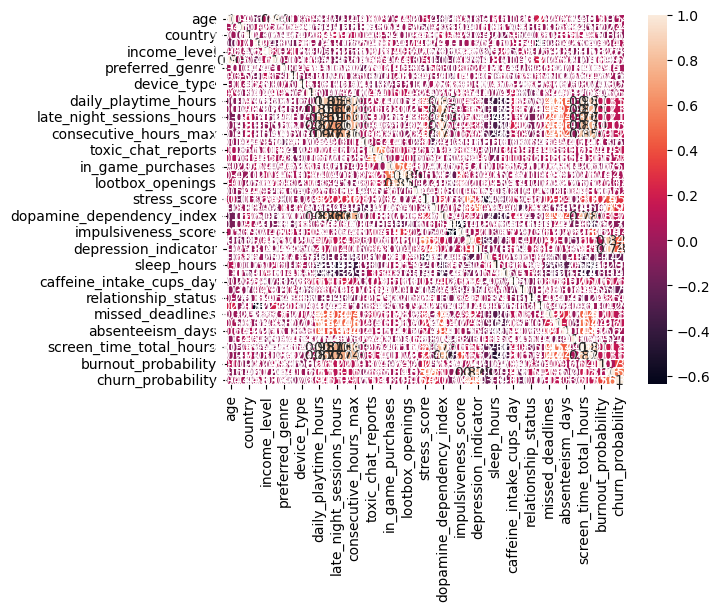

In [31]:
sns.heatmap(corr,annot=True)

In [32]:
le

LabelEncoder()

In [33]:
X.columns

Index(['age', 'gender', 'country', 'occupation', 'income_level',
       'years_gaming', 'preferred_genre', 'platform', 'device_type',
       'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions',
       'late_night_sessions_hours', 'weekend_playtime_hours',
       'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports',
       'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd',
       'lootbox_openings', 'subscription_status', 'stress_score',
       'loneliness_score', 'dopamine_dependency_index', 'self_control_score',
       'impulsiveness_score', 'anxiety_level', 'depression_indicator',
       'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week',
       'caffeine_intake_cups_day', 'social_interaction_hours',
       'relationship_status', 'gpa_or_performance_score', 'missed_deadlines',
       'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps',
       'screen_time_total_hours', 'burnout_probability',
       'mental_hea

In [34]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2, random_state = 42)

In [35]:
X_train

,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,...,relationship_status,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,burnout_probability,mental_health_risk_score,churn_probability
141,34,1,13,1,0,21,5,2,3,6,...,4,4.00,2,9.6,3,183.0,4.0,1.0,0.560,0.723
60,22,1,10,4,1,10,5,3,5,2,...,4,4.00,0,9.5,6,149.7,8.1,1.0,0.435,0.901
212,16,1,12,2,3,4,0,1,0,6,...,4,4.00,4,20.6,5,30.0,8.3,1.0,0.765,0.838
193,23,1,7,2,1,11,8,2,3,0,...,2,4.00,0,5.3,0,74.9,2.1,1.0,0.435,0.824
215,23,1,3,0,2,11,5,2,3,5,...,1,4.00,2,16.7,10,204.7,13.7,1.0,0.675,0.939
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,21,1,2,3,4,8,4,1,5,0,...,1,3.04,3,18.2,1,5.0,4.5,1.0,0.595,0.802
14,27,1,1,0,1,14,1,2,1,2,...,4,4.00,1,9.4,1,149.9,6.2,1.0,0.500,0.879
93,19,1,0,3,3,7,3,0,1,1,...,4,3.08,2,3.6,4,134.7,3.9,1.0,0.540,0.886
185,17,1,14,4,1,5,1,1,2,6,...,4,4.00,7,16.8,10,139.2,12.1,1.0,0.530,0.872


In [36]:
Y_train

141    26.17
60     33.65
212    54.35
193    20.35
215    47.86
       ...  
108    19.49
14     27.81
93     20.99
185    53.41
104    58.05
Name: addiction_score, Length: 192, dtype: float64

In [37]:
X_test

,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,...,relationship_status,gpa_or_performance_score,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,burnout_probability,mental_health_risk_score,churn_probability
24,13,1,6,3,1,1,7,2,4,3,...,4,3.28,3,9.5,3,126.4,7.5,1.000,0.550,0.692
6,27,1,13,4,2,15,6,0,0,6,...,1,4.00,2,30.2,12,5.0,10.0,1.000,0.550,0.879
94,29,1,3,1,2,17,1,0,5,6,...,2,4.00,1,25.5,6,22.8,6.1,1.000,0.680,1.000
111,15,1,2,0,1,3,6,1,3,4,...,4,4.00,0,22.1,8,46.6,6.5,1.000,0.660,0.935
106,29,1,14,0,4,15,7,3,2,6,...,3,4.00,2,10.2,4,94.4,8.0,1.000,0.780,0.768
178,30,0,10,0,2,18,1,4,2,5,...,2,4.00,0,41.7,6,67.1,11.6,1.000,0.630,0.891
242,19,1,2,0,1,6,5,2,0,4,...,3,4.00,2,26.3,5,182.4,11.5,1.000,0.500,0.881
87,27,1,13,1,4,15,9,0,0,5,...,4,4.00,3,23.9,6,62.6,10.4,1.000,0.690,0.936
9,30,0,1,1,3,18,9,0,3,2,...,1,4.00,2,24.8,3,22.2,7.5,1.000,0.290,0.756
145,17,1,6,3,3,5,9,0,5,2,...,4,3.14,3,15.8,4,112.1,7.1,1.000,0.405,0.839


In [38]:
Y_test

24     45.58
6      34.82
94     24.75
111    25.54
106    43.93
178    44.79
242    55.20
87     47.05
9      46.24
145    30.32
45     37.67
214    55.09
116    31.14
172    54.82
115    40.00
239    43.32
191    50.67
15     47.67
154    21.20
127    48.05
129    48.65
19     20.25
244    36.42
30     29.01
182    14.53
152    31.34
10     37.67
209    68.00
246    22.45
155    39.91
97     43.71
237    30.54
25     38.57
188    29.87
18     21.80
69     63.24
199    38.94
55     48.22
79     57.23
181    19.25
235    36.58
114    31.40
229    40.86
16     49.49
158    45.88
66     42.42
167    54.22
38     61.25
Name: addiction_score, dtype: float64

In [39]:
model = LinearRegression()

In [41]:
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
Y_pred = model.predict(X_test)

In [43]:
Y_pred

array([43.42509098, 40.82124883, 28.1865761 , 29.15396345, 42.66516736,
       45.0212244 , 55.95875724, 52.01976674, 48.7499575 , 33.67060059,
       38.57081041, 57.93231606, 25.36631709, 53.60960405, 39.60310677,
       47.75018284, 53.62080604, 51.08576083, 21.18508637, 43.84716355,
       41.15933529, 22.7027478 , 37.32843947, 29.43340833, 14.79403947,
       37.02543235, 39.49197515, 64.91347012, 21.85604086, 36.56594774,
       44.72321123, 30.87422311, 37.88707974, 30.2281857 , 23.1110115 ,
       58.33411907, 38.88128399, 49.03627864, 57.07669863, 19.73395491,
       43.9675649 , 37.81911157, 41.53972281, 43.68643189, 51.01849589,
       44.51726656, 52.93205528, 56.72514676])

In [44]:
model.score(X_train,Y_train)

0.9632465318790575

In [45]:
model.score(X_test,Y_test)

0.9251267331327935

In [46]:
i = model.intercept_

In [47]:
i

np.float64(25.750410454116192)

In [48]:
c = model.coef_

In [49]:
c

array([-1.52792910e-01, -3.28263420e-01,  2.04280980e-02,  4.43288373e-02,
        1.01867520e-01,  2.58370072e-01, -9.58647922e-03,  9.93464329e-02,
        1.44475048e-01,  1.77850237e-02,  2.25248053e+00,  1.55862000e-01,
        2.13222468e+00,  1.60108884e-02, -1.23717772e-01, -6.89137686e-01,
       -2.59024925e-02,  2.36201092e-01,  4.98972610e-02, -1.47578082e-02,
       -1.87116249e-02, -3.37714655e-01,  4.69672746e-02, -3.09223518e-01,
        1.76444772e+00, -1.67327650e+00,  1.04460008e+00, -8.09045434e-01,
       -4.61717733e-01,  1.90527655e-01, -1.05167800e+00, -7.05467991e-02,
       -2.49876175e-01, -3.02530605e-02,  1.31159797e-01,  9.01730874e-02,
        7.93250744e-02,  6.96894254e-04, -1.25246379e-02, -3.44434655e-03,
       -3.54464382e-01,  3.97548961e+00,  1.56314745e+01, -1.49870648e+00])